C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_15244\2872463948.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None)


Slope: [0.83612965]
Intercept: 0.011344468906702711


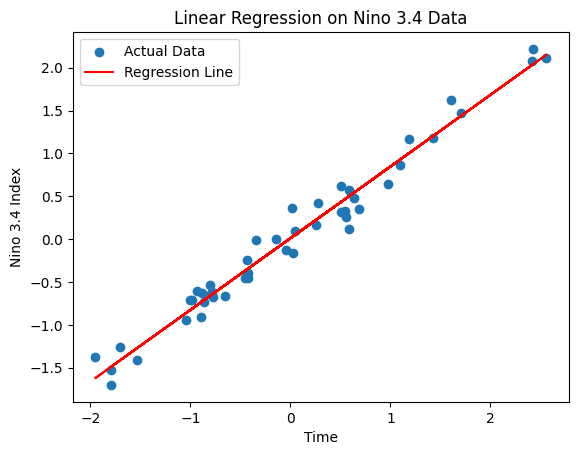

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load the data
file_path = "nino-3.4_7924_noaa.txt"
data = pd.read_csv(file_path, delim_whitespace=True, header=None)

# Suppose column 0 = year, column 1 = value
X = data.iloc[:,0].values.reshape(-1,1)   # Independent variable
y = data.iloc[:,1].values                 # Dependent variable

# Create Linear Regression Model
model = LinearRegression()
model.fit(X, y)

# Prediction
y_pred = model.predict(X)

# Print results
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

# Plot
plt.scatter(X, y, label="Actual Data")
plt.plot(X, y_pred, color='red', label="Regression Line")
plt.xlabel("Time")
plt.ylabel("Nino 3.4 Index")
plt.title("Linear Regression on Nino 3.4 Data")
plt.legend()
plt.show()

C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_15244\1934912316.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  enso = pd.read_csv(enso_file, delim_whitespace=True, header=None)


Slope (ENSO influence on SST): 0.03706465558140896
Intercept: 286.79358270797
R² score: 0.06657404637737319


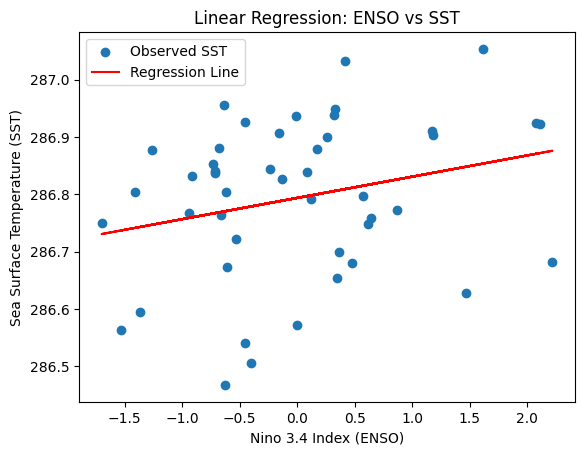

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from sklearn.linear_model import LinearRegression

# -----------------------------
# Load ENSO (Nino 3.4) data
# -----------------------------
enso_file = "nino-3.4_7924_noaa.txt"
enso = pd.read_csv(enso_file, delim_whitespace=True, header=None)

# ENSO index
enso_index = enso.iloc[:,1].values

# -----------------------------
# Load SST NetCDF file
# -----------------------------
sst_file = "ERA5_SST_sst_K_monmean_7924_1.nc"
ds = xr.open_dataset(sst_file)

# Extract SST variable
sst = ds['sst']

# Calculate global mean SST
sst_mean = sst.mean(dim=["lat","lon"])

# Convert to pandas
sst_values = sst_mean.values

# -----------------------------
# Match ENSO and SST length
# -----------------------------
min_len = min(len(enso_index), len(sst_values))

X = enso_index[:min_len].reshape(-1,1)   # ENSO (Independent variable)
y = sst_values[:min_len]                 # SST (Dependent variable)

# -----------------------------
# Linear Regression Model
# -----------------------------
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# -----------------------------
# Results
# -----------------------------
print("Slope (ENSO influence on SST):", model.coef_[0])
print("Intercept:", model.intercept_)
print("R² score:", model.score(X,y))

# -----------------------------
# Plot
# -----------------------------
plt.scatter(X, y, label="Observed SST")
plt.plot(X, y_pred, color="red", label="Regression Line")

plt.xlabel("Nino 3.4 Index (ENSO)")
plt.ylabel("Sea Surface Temperature (SST)")
plt.title("Linear Regression: ENSO vs SST")

plt.legend()
plt.show()

C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_15244\449959748.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  enso = pd.read_csv(enso_file, delim_whitespace=True, header=None)
C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_15244\449959748.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


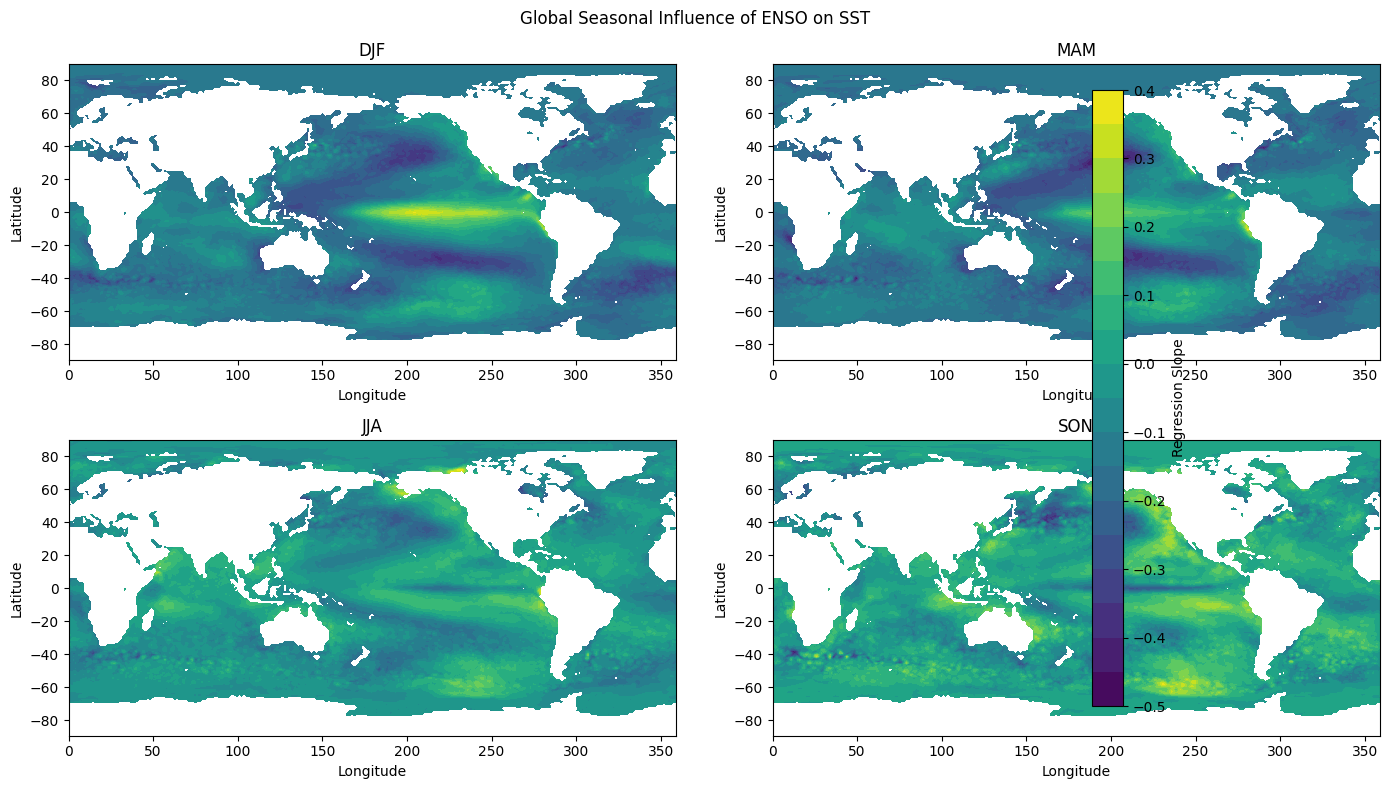

In [4]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load ENSO data

enso_file = "nino-3.4_7924_noaa.txt"
enso = pd.read_csv(enso_file, delim_whitespace=True, header=None)

enso_index = enso.iloc[:,1].values

# Convert yearly ENSO → monthly
enso_monthly = np.repeat(enso_index, 12)

# Load SST dataset
sst_file = "ERA5_SST_sst_K_monmean_7924_1.nc"

ds = xr.open_dataset(sst_file)
sst = ds["sst"]

time = ds["time"]
lat = ds["lat"]
lon = ds["lon"]

# Match ENSO length
enso_monthly = enso_monthly[:len(time)]

ds["enso"] = (("time"), enso_monthly)

# Define seasons

seasons = {
    "DJF":[12,1,2],
    "MAM":[3,4,5],
    "JJA":[6,7,8],
    "SON":[9,10,11]
}


fig, axes = plt.subplots(2,2, figsize=(14,8))

axes = axes.flatten()

# Seasonal regression

for idx,(season, months) in enumerate(seasons.items()):

    season_ds = ds.sel(time=ds["time"].dt.month.isin(months))

    enso = season_ds["enso"].values
    sst = season_ds["sst"].values

    slope_map = np.zeros((len(lat), len(lon)))

    for i in range(len(lat)):
        for j in range(len(lon)):

            y = sst[:, i, j]

            if np.isnan(y).any():
                slope_map[i,j] = np.nan
                continue

            X = enso.reshape(-1,1)

            model = LinearRegression()
            model.fit(X,y)

            slope_map[i,j] = model.coef_[0]

    ax = axes[idx]

    c = ax.contourf(lon, lat, slope_map, 20)

    ax.set_title(season)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

# Colorbar
fig.colorbar(c, ax=axes.ravel().tolist(), label="Regression Slope")

plt.suptitle("Global Seasonal Influence of ENSO on SST")

plt.tight_layout()

plt.show()

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import t

# Load data
file_path = "nino-3.4_7924_noaa.txt"
data = pd.read_csv(file_path, delim_whitespace=True, header=None)

X = data.iloc[:,0].values.reshape(-1,1)
y = data.iloc[:,1].values

# Fit model
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_15244\1483251125.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None)


In [8]:
n = len(y)
p = 1  # number of predictors

residuals = y - y_pred
s_err = np.sqrt(np.sum(residuals**2) / (n - p - 1))

In [9]:
t_val = t.ppf(0.975, df=n-p-1)  # 95% CI

x_mean = np.mean(X)
Sxx = np.sum((X - x_mean)**2)

ci = t_val * s_err * np.sqrt(1/n + ((X - x_mean)**2 / Sxx))

upper = y_pred + ci.flatten()
lower = y_pred - ci.flatten()

In [10]:
inside_ci = (y >= lower) & (y <= upper)
outside_ci = ~inside_ci

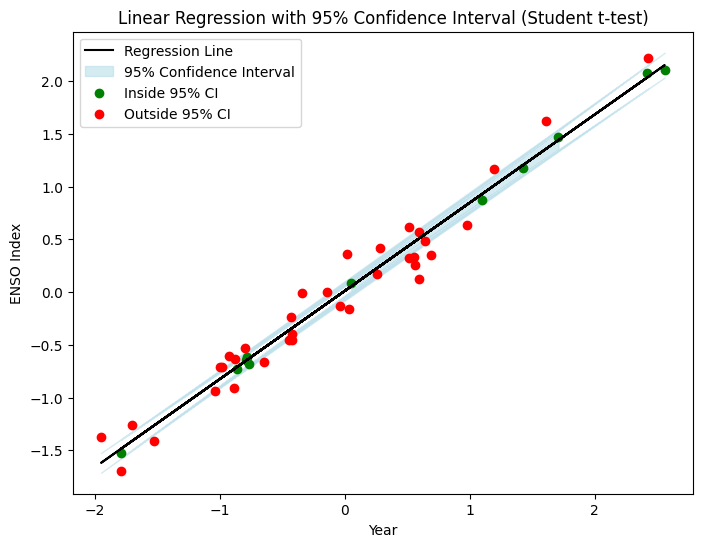

In [11]:
plt.figure(figsize=(8,6))

# Regression line
plt.plot(X, y_pred, color='black', label='Regression Line')

# Confidence interval band
plt.fill_between(X.flatten(), lower, upper, color='lightblue', alpha=0.5,
                 label='95% Confidence Interval')

# Points inside CI
plt.scatter(X[inside_ci], y[inside_ci], color='green', label='Inside 95% CI')

# Points outside CI
plt.scatter(X[outside_ci], y[outside_ci], color='red', label='Outside 95% CI')

plt.xlabel("Year")
plt.ylabel("ENSO Index")
plt.title("Linear Regression with 95% Confidence Interval (Student t-test)")
plt.legend()
plt.show()

C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_15244\3993455490.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  enso = pd.read_csv(enso_file, delim_whitespace=True, header=None)
C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_15244\3993455490.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


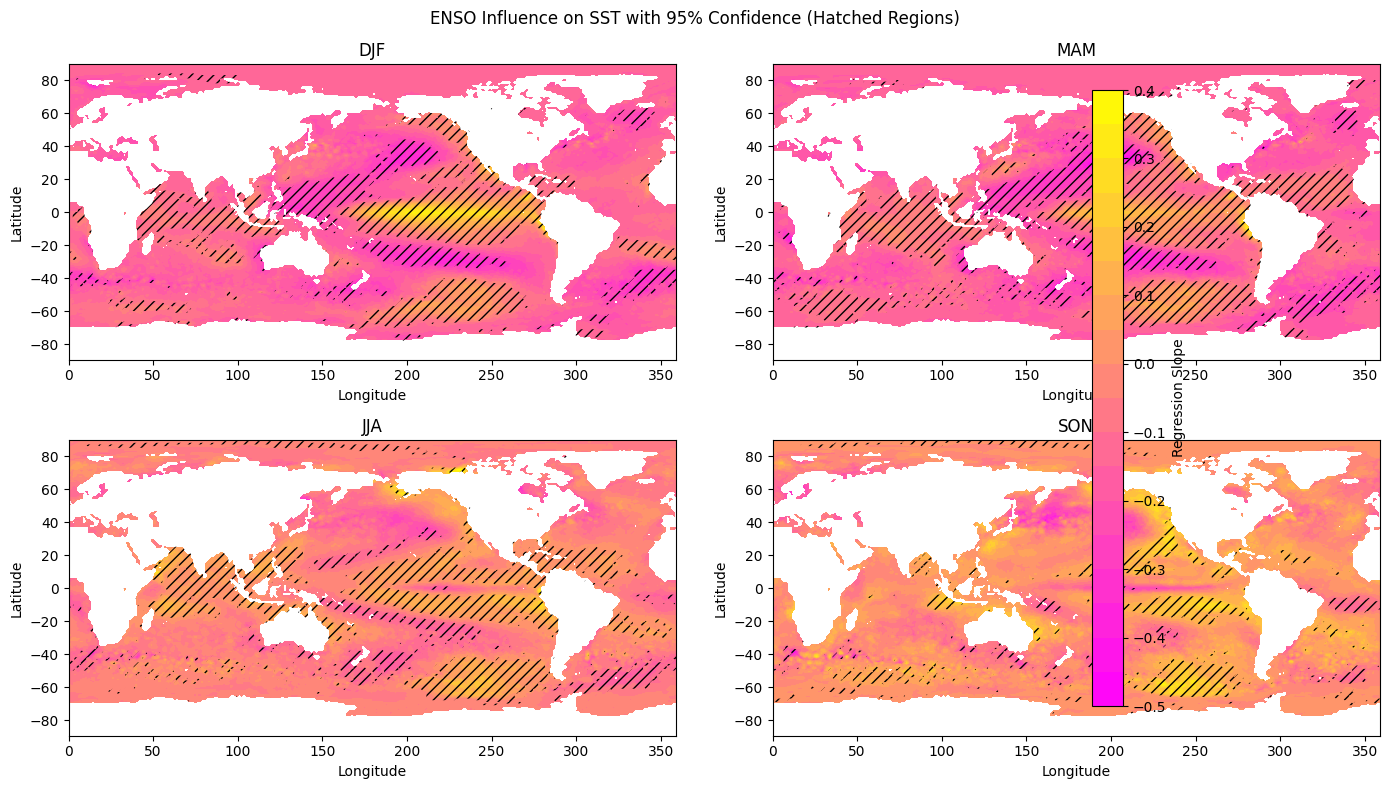

In [ ]:
#95 percent
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import t

# -----------------------------
# Load ENSO
# -----------------------------
enso_file = "nino-3.4_7924_noaa.txt"
enso = pd.read_csv(enso_file, delim_whitespace=True, header=None)

enso_index = enso.iloc[:,1].values
enso_monthly = np.repeat(enso_index,12)

# -----------------------------
# Load SST dataset
# -----------------------------
sst_file = "ERA5_SST_sst_K_monmean_7924_1.nc"

ds = xr.open_dataset(sst_file)

lat = ds["lat"].values
lon = ds["lon"].values
time = ds["time"]

enso_monthly = enso_monthly[:len(time)]
ds["enso"] = (("time"), enso_monthly)

# -----------------------------
# Seasons
# -----------------------------
seasons = {
    "DJF":[12,1,2],
    "MAM":[3,4,5],
    "JJA":[6,7,8],
    "SON":[9,10,11]
}

fig, axes = plt.subplots(2,2, figsize=(14,8))
axes = axes.flatten()

for idx,(season,months) in enumerate(seasons.items()):

    season_ds = ds.sel(time=ds["time"].dt.month.isin(months))

    X = season_ds["enso"].values
    Y = season_ds["sst"].values

    n = len(X)

    # anomalies
    X_anom = X - X.mean()
    Y_anom = Y - Y.mean(axis=0)

    # regression slope
    slope = np.sum(X_anom[:,None,None]*Y_anom,axis=0) / np.sum(X_anom**2)

    # predicted values
    Y_pred = slope[None,:,:] * X_anom[:,None,None]

    residual = Y_anom - Y_pred

    sigma2 = np.sum(residual**2,axis=0)/(n-2)

    Sxx = np.sum(X_anom**2)

    SE = np.sqrt(sigma2/Sxx)

    # t statistic
    t_stat = slope/SE

    t_crit = t.ppf(0.975,n-2)

    significance = np.abs(t_stat) > t_crit

    ax = axes[idx]

    # main regression map
    c = ax.contourf(lon, lat, slope, 20, cmap="spring")

    # hatch for significant region
    ax.contourf(
        lon,
        lat,
        significance,
        levels=[0.5,1],
        hatches=['///'],
        colors='none'
    )

    ax.set_title(season)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.colorbar(c, ax=axes.ravel().tolist(), label="Regression Slope")

plt.suptitle("ENSO Influence on SST with 95% Confidence (Hatched Regions)")

plt.tight_layout()
plt.show()